# Study 13 — Can we distinguish genuine ability change from ordinary random variation?

Studies 07–12 examined how different estimators respond when a player's underlying ability changes.

But those studies gave us something we do not have in reality: knowledge of the player's true underlying frame-win probability.

In real sport, we observe results — wins and losses — but not ability itself.

A run of stronger results could therefore mean two very different things:

- the player's underlying ability has genuinely improved;
- the player's ability has not changed and the stronger results are ordinary random variation.

This study moves from **tracking a known change** to **deciding whether a change happened at all**.

We will compare two deliberately controlled worlds:

1. **No-change world** — true frame-win probability remains at 58%.
2. **Real-change world** — true frame-win probability begins at 58% and later changes permanently to 64%.

Apart from that difference, the worlds will be identical.

The detector will not be allowed to observe the true probability path. It will see only simulated frame results.

The central question is:

> **Can evidence based on observed results reliably distinguish a genuine change in ability from the apparent changes produced by ordinary randomness?**

The aim is not yet to build the best possible change-point detector.

First we want to establish the fundamental inference problem:

> **Random variation can produce convincing-looking evidence of change when no change occurred, while a genuine change can initially look like ordinary noise.**

## Experimental design

We will start with the simplest possible detection problem.

Each simulated career contains 1,500 frames.

For the first 1,000 frames, both worlds are identical:

- true frame-win probability = 58%.

After frame 1,000:

- **No-change world:** true probability remains at 58%;
- **Real-change world:** true probability increases permanently to 64%.

Frames remain independent conditional on the current true probability.

We deliberately know the true change point when constructing the simulation, but the detection statistic will not be allowed to use the underlying probability values. It will work only from observed wins and losses.

To keep the study small, we will initially ask a very specific question:

> **After the possible change point, how unusual does recent performance look compared with what we would expect from a player who is still genuinely a 58% player?**

This gives us a simple benchmark for distinguishing the two worlds without yet introducing a full change-point algorithm.

The important comparison will be between the distributions of evidence produced in the two worlds.

If those distributions overlap substantially, then even a sensible detector must sometimes:

- signal a change when none occurred;
- fail to recognise a genuine change.

That overlap is the phenomenon we want Study 13 to expose.

## A deliberately simple detector

We will begin with a fixed post-change observation window of **250 frames**.

This is deliberately simple and also keeps continuity with the 250-frame memory used in Studies 08–12.

For each simulated career, we will look at frames **1,001–1,250** and count how many were won.

Under the no-change hypothesis, the player is still genuinely a 58% player. Therefore, if nothing has changed, the number of wins in those 250 frames follows:

$$
X \sim \mathrm{Binomial}(250, 0.58)
$$

This notation says that **\(X\)** — the number of frames won — follows a binomial distribution with:

- **250 trials:** the 250 observed frames;
- **0.58 probability of success:** a 58% chance of winning each frame.

Here, a "success" simply means winning a frame.

The binomial model applies because we are assuming that each frame has the same win probability and that frames are independent of one another.

So \(X\) can take any whole-number value from 0 to 250. Some totals are much more likely than others.

If the player really remains a 58% player, the expected number of wins is:

$$
250 \times 0.58 = 145
$$

That does **not** mean the player will win exactly 145 frames. Random variation means totals somewhat above or below 145 will occur naturally.

Under the real-change world, those same 250 results instead come from a player whose true probability has risen to 64%:

$$
X \sim \mathrm{Binomial}(250, 0.64)
$$

The interpretation is the same, except each frame now has a 64% chance of being won.

The expected number of wins becomes:

$$
250 \times 0.64 = 160
$$

Again, 160 is an average over repeated sets of 250 frames, not a guaranteed result.

The statistic itself will simply be:

> **The number of wins in the first 250 frames after the possible change point.**

A larger total provides more evidence that the player's underlying ability may have improved.

This is not yet a general change-point detector.

We are giving the analysis the location of a **suspected** change and asking whether the subsequent results contain enough information to distinguish:

- a player who remained at 58%;
- a player who genuinely moved to 64%.

That deliberately easier problem is useful because, if the two worlds are difficult to distinguish even here, the harder problem of detecting an unknown change point will necessarily face the same underlying ambiguity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

# Keep the experiment deliberately controlled: the two worlds differ only
# in the player's true probability after the suspected change point.
p_before = 0.58
p_no_change = 0.58
p_real_change = 0.64

change_frame = 1_000
window_size = 250
career_frames = 1_500

# The detector observes only the first 250 frames after the suspected change.
possible_wins = np.arange(window_size + 1)

no_change_pmf = binom.pmf(possible_wins, window_size, p_no_change)
real_change_pmf = binom.pmf(possible_wins, window_size, p_real_change)

no_change_mean = window_size * p_no_change
real_change_mean = window_size * p_real_change

print(f"No-change expected wins: {no_change_mean:.1f} / {window_size}")
print(f"Real-change expected wins: {real_change_mean:.1f} / {window_size}")
print(f"Difference in expected wins: {real_change_mean - no_change_mean:.1f}")

No-change expected wins: 145.0 / 250
Real-change expected wins: 160.0 / 250
Difference in expected wins: 15.0


## How large is ordinary random variation?

The two worlds differ by **15 expected wins** over 250 frames:

- no change: expected wins = 145;
- real change: expected wins = 160.

But that difference only becomes meaningful once we compare it with the amount of variation we would normally expect from repeated sets of 250 frames.

For a binomial distribution,

$$
X \sim \mathrm{Binomial}(n, p)
$$

the standard deviation of the number of wins is:

$$
\sqrt{np(1-p)}
$$

This tells us roughly how much the observed win total naturally moves around its expected value from one 250-frame sample to another.

For the no-change world:

$$
\sqrt{250 \times 0.58 \times 0.42}
\approx 7.80
$$

For the real-change world:

$$
\sqrt{250 \times 0.64 \times 0.36}
\approx 7.59
$$

So although the two worlds are separated by 15 wins on average, each distribution naturally varies by roughly **7–8 wins**.

That immediately suggests the central difficulty.

A strong-looking 250-frame run can occur even when the player's ability has not changed, while a genuinely improved player can still produce an ordinary-looking total.

The question is therefore not simply whether the two expected values differ.

It is:

> **How much do the two distributions overlap?**

In the chart below, **unlike the career-path charts in the previous studies, the horizontal axis is not frame number**. It is the **total number of wins observed in one 250-frame sample**.

So a value of 145 on the horizontal axis means **145 wins from 250 frames**, while 160 means **160 wins from 250 frames**.

Each curve shows how likely the different possible 250-frame win totals are in one of our two worlds.

No-change standard deviation: 7.80 wins
Real-change standard deviation: 7.59 wins
Difference between expected totals: 15.0 wins


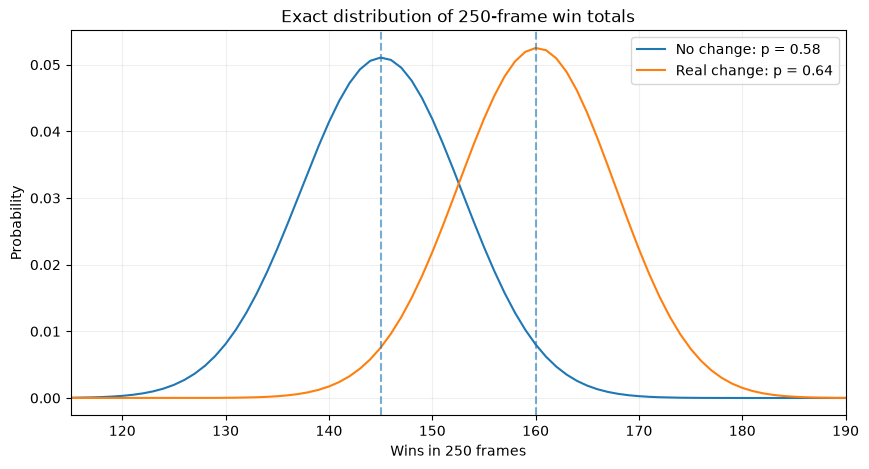

In [2]:
# Quantify the ordinary sampling variation in each 250-frame world.
no_change_sd = np.sqrt(window_size * p_no_change * (1 - p_no_change))
real_change_sd = np.sqrt(window_size * p_real_change * (1 - p_real_change))

print(f"No-change standard deviation: {no_change_sd:.2f} wins")
print(f"Real-change standard deviation: {real_change_sd:.2f} wins")
print(
    f"Difference between expected totals: "
    f"{real_change_mean - no_change_mean:.1f} wins"
)

# Plot the exact distributions rather than relying on a particular simulation.
plt.figure(figsize=(10, 5))

plt.plot(
    possible_wins,
    no_change_pmf,
    label="No change: p = 0.58"
)

plt.plot(
    possible_wins,
    real_change_pmf,
    label="Real change: p = 0.64"
)

plt.axvline(
    no_change_mean,
    linestyle="--",
    alpha=0.6
)

plt.axvline(
    real_change_mean,
    linestyle="--",
    alpha=0.6
)

plt.xlim(115, 190)
plt.xlabel("Wins in 250 frames")
plt.ylabel("Probability")
plt.title("Exact distribution of 250-frame win totals")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## The two worlds are different, but not cleanly separated

The chart shows that a genuine increase from 58% to 64% does move the distribution noticeably to the right.

The most likely results are centred around:

- **145 wins** if ability remained at 58%;
- **160 wins** if ability genuinely increased to 64%.

But the distributions still overlap.

For example, a total in the low-to-mid 150s is not obviously attributable to either world.

A 58% player can reach that level through an unusually strong run.

A genuine 64% player can also produce the same total through an unusually weak run.

This is the key inference problem:

> **Observed improvement is evidence of an ability change, but it is not proof of one.**

Equally:

> **A genuine ability change does not guarantee that the observed results will immediately look unusual.**

The next step is to quantify this overlap rather than judge it only by eye.

## The two worlds overlap

The chart shows that a genuine increase from 58% to 64% shifts the distribution of results to the right.

If ability remains at 58%, results tend to cluster around **145 wins from 250**.

If ability genuinely rises to 64%, results tend to cluster around **160 wins from 250**.

But neither total is guaranteed.

Because of ordinary random variation:

- a 58% player can sometimes produce a result well above 145;
- a 64% player can sometimes produce a result well below 160.

That creates the region where the two curves overlap.

For example, if we observed something around **150–155 wins**, that result would be compatible with either world.

It would be relatively strong performance for a player who remained at 58%, but relatively weak performance for a player who genuinely improved to 64%.

This is the central problem Study 13 is trying to expose:

> **The same observed run of results can be produced by different underlying abilities.**

So observed improvement can be evidence that ability changed without proving that it did.

Conversely, a genuine improvement in ability can occur without producing immediately convincing evidence in the results.

The next step is to measure how much the two exact distributions overlap rather than relying only on the visual impression.

In [3]:
# Measure the exact amount of probability shared by the two distributions.
# At each possible win total, the overlap is the smaller of the two probabilities.
overlap_pmf = np.minimum(no_change_pmf, real_change_pmf)
overlap_probability = overlap_pmf.sum()

print(f"Exact distribution overlap: {overlap_probability:.3f}")
print(f"Exact distribution overlap: {overlap_probability:.1%}")

Exact distribution overlap: 0.330
Exact distribution overlap: 33.0%


## What does 33% overlap mean?

The two exact distributions have an overlap of approximately **33.0%**.

This does **not** mean that 33% of individual observations are automatically impossible to classify, nor does it mean that there is a 33% chance that a particular apparent improvement is random.

Instead, the overlap measures how much probability mass the two possible worlds have in common.

At every possible 250-frame win total, we take whichever of the two probabilities is smaller and add those shared amounts together.

The result is:

> **About one-third of the probability represented by these two distributions lies in outcomes that both worlds can produce with meaningful probability.**

That is a substantial amount of overlap given that the true underlying abilities differ by six percentage points.

The reason is sampling variation.

A 58% player can occasionally produce a very strong 250-frame run, while a 64% player can occasionally produce a relatively weak one.

So even with a genuine and permanent ability increase, observed results do not divide neatly into:

- "no change";
- "real change".

There is an unavoidable region of uncertainty between them.

This gives us our first quantitative statement about the detection problem:

> **A genuine change from 58% to 64% creates noticeably different results over 250 frames, but the resulting evidence still overlaps substantially with ordinary variation from an unchanged 58% player.**

The next question is practical:

> **If we had to choose a win-total threshold and actually declare that a change had occurred, what kinds of mistakes would we make?**

## Turning evidence into a decision

So far we have treated the 250-frame win total as evidence.

But a detector eventually has to make a decision.

To keep that decision deliberately simple, we will use a fixed threshold:

> **Declare that ability has improved if the player wins at least 153 of the 250 frames.**

Why 153?

The two expected totals are:

- 145 wins in the no-change world;
- 160 wins in the real-change world.

The midpoint between them is:

$$
\frac{145 + 160}{2} = 152.5
$$

Since the number of wins must be a whole number, we use **153 wins** as the threshold.

This is not being presented as an optimised or uniquely correct detector.

It is simply a transparent rule that lets us turn the overlapping distributions into actual decisions.

That creates two important kinds of error.

### False alarm

The player is still genuinely a 58% player, but random variation produces at least 153 wins and we incorrectly declare an improvement.

### Missed change

The player genuinely improved to 64%, but produces fewer than 153 wins and we fail to detect the change.

These two mistakes are the practical consequence of the overlap we have just seen.

The next step is to calculate their exact probabilities.

In [4]:
threshold = 153

# scipy's binom.cdf(k, n, p) gives the probability of observing
# k wins or fewer from n independent trials with success probability p.
#
# Our detector requires at least 153 wins, so a genuine 64% player is
# missed whenever they record 152 wins or fewer.
missed_change_probability = binom.cdf(
    threshold - 1,
    window_size,
    p_real_change
)

# binom.sf(k, n, p) is the "survival function": the probability of
# observing more than k wins.
#
# Therefore sf(152) gives the probability of 153 wins or more.
# In the no-change world, reaching that threshold is a false alarm.
false_alarm_probability = binom.sf(
    threshold - 1,
    window_size,
    p_no_change
)

correct_no_change_probability = 1 - false_alarm_probability
detected_change_probability = 1 - missed_change_probability

print(f"Threshold: {threshold} wins from {window_size}")
print()
print(f"False alarm:       {false_alarm_probability:.1%}")
print(f"Correct no-change: {correct_no_change_probability:.1%}")
print(f"Missed change:     {missed_change_probability:.1%}")
print(f"Detected change:   {detected_change_probability:.1%}")

Threshold: 153 wins from 250

False alarm:       16.8%
Correct no-change: 83.2%
Missed change:     16.1%
Detected change:   83.9%


## A simple detector still makes substantial errors

Using a threshold of **153 wins from 250 frames** produces:

- **16.8% false alarms** — the player is still genuinely at 58%, but random variation makes the results look strong enough to declare an improvement;
- **16.1% missed changes** — the player really has improved to 64%, but the observed results are not strong enough to cross the threshold.

Equivalently, the rule makes the correct decision about:

- **83.2%** of unchanged 58% cases;
- **83.9%** of genuine 64% cases.

This is an important distinction from the earlier studies.

The detector is not failing because it estimates the data incorrectly. It is failing because the **data themselves are sometimes ambiguous**.

A genuinely unchanged player can produce 153 or more wins through ordinary randomness.

A genuinely improved player can produce fewer than 153 wins for exactly the same reason.

So even though we deliberately made this detection problem relatively easy — we know where the suspected change occurred, we know the two possible ability levels, and we observe 250 subsequent frames — there is still no decision rule that can make the two underlying worlds perfectly separable from these results.

The approximately equal error rates are also consistent with the **33% distribution overlap** seen earlier.

Very roughly, when the two worlds are treated symmetrically, that shared probability mass translates into an unavoidable classification error of about half the overlap:

$$
\frac{33\%}{2} \approx 16.5\%
$$

which is close to the error rates produced by our simple 153-win threshold.

The central lesson is becoming clearer:

> **Randomness does not merely make ability difficult to estimate precisely. It can make genuinely different underlying abilities produce observationally similar evidence.**

## Changing the threshold changes the kind of mistake we make

The 153-win threshold was deliberately simple, not uniquely correct.

If we lower the threshold, the detector becomes more willing to declare that ability has improved.

That has two consequences:

- **fewer genuine improvements are missed**;
- **more unchanged players trigger false alarms**.

If we raise the threshold, the opposite happens:

- **fewer false alarms occur**;
- **more genuine improvements are missed**.

So there is no threshold that simply removes the uncertainty.

Instead, the threshold determines how that uncertainty is divided between the two kinds of error.

This is a general feature of detection problems:

> **Demanding stronger evidence protects against false alarms, but makes genuine changes harder to detect.**

The next step is to calculate that trade-off across a range of possible win thresholds.

In [5]:
# Examine how the decision trade-off changes as we move the win threshold.
thresholds = np.arange(140, 171)

tradeoff_rows = []

for t in thresholds:
    # False alarm: unchanged 58% player still reaches the threshold.
    false_alarm = binom.sf(
        t - 1,
        window_size,
        p_no_change
    )

    # Detection rate: genuinely improved 64% player reaches the threshold.
    detected_change = binom.sf(
        t - 1,
        window_size,
        p_real_change
    )

    tradeoff_rows.append({
        "threshold": t,
        "false_alarm_rate": false_alarm,
        "detection_rate": detected_change,
        "missed_change_rate": 1 - detected_change,
    })

tradeoff = pd.DataFrame(tradeoff_rows)

tradeoff.head()

,threshold,false_alarm_rate,detection_rate,missed_change_rate
0,140,0.760027,0.996199,0.003801
1,141,0.718637,0.994469,0.005531
2,142,0.674045,0.992069,0.007931
3,143,0.626777,0.988795,0.011205
4,144,0.577478,0.984399,0.015601


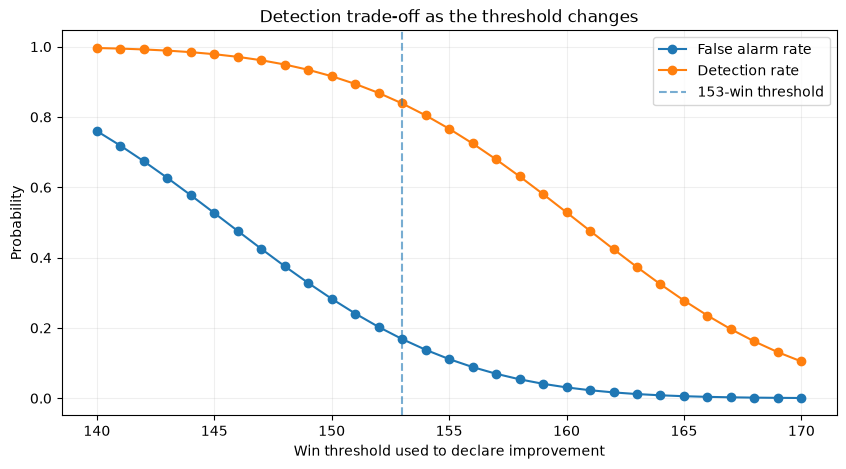

In [6]:
# Plot how moving the decision threshold changes the balance between
# false alarms and successful detection of a genuine improvement.
plt.figure(figsize=(10, 5))

plt.plot(
    tradeoff["threshold"],
    tradeoff["false_alarm_rate"],
    marker="o",
    label="False alarm rate"
)

plt.plot(
    tradeoff["threshold"],
    tradeoff["detection_rate"],
    marker="o",
    label="Detection rate"
)

plt.axvline(
    153,
    linestyle="--",
    alpha=0.6,
    label="153-win threshold"
)

plt.xlabel("Win threshold used to declare improvement")
plt.ylabel("Probability")
plt.title("Detection trade-off as the threshold changes")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## There is no threshold that removes the uncertainty

The chart makes the trade-off explicit.

At a low win threshold, the detector is very sensitive.

It identifies almost every genuine improvement, but it also declares improvement for many players whose true ability never changed.

As the threshold rises, false alarms become less common.

But the price is that the detector also becomes less likely to recognise genuine improvements.

For example, around our 153-win threshold:

- the false-alarm rate is about **16.8%**;
- the detection rate is about **83.9%**.

Moving the threshold higher would reduce the first number, but it would also reduce the second.

Moving it lower would detect more genuine changes, but would create more false alarms.

So the threshold does not solve the ambiguity in the observed results.

It only determines **which kind of mistake we are more willing to make**.

This is an important conceptual shift from the earlier studies:

> **Once the underlying ability is hidden, uncertainty is no longer just about estimating its level. It is also about deciding whether it changed at all.**

And that decision cannot be made perfectly from a finite run of noisy results.

## More evidence should make genuine change easier to detect

So far, every decision has been based on exactly **250 post-change frames**.

But 250 frames is only one possible evidence window.

If we observe very few frames after the suspected change point, random variation should dominate and the two worlds should be hard to distinguish.

If we observe many more frames, the average result should settle more closely around the player's true underlying probability.

That suggests a simple expectation:

> **The longer we observe the player after the suspected change, the easier it should become to distinguish a genuine 64% player from an unchanged 58% player.**

To test this without introducing a new detection method, we will repeat the same midpoint-threshold idea using several different post-change window sizes:

- 25 frames;
- 50 frames;
- 100 frames;
- 250 frames;
- 500 frames.

For each window size, we will:

1. calculate the expected win total under 58%;
2. calculate the expected win total under 64%;
3. place the decision threshold at the midpoint between those expectations;
4. calculate the resulting false-alarm and missed-change probabilities.

This keeps the detector deliberately simple.

The only thing changing is **how much evidence we allow it to see**.

In [7]:
# Repeat the same simple midpoint-threshold detector with different
# amounts of post-change evidence.
evidence_windows = [25, 50, 100, 250, 500]

evidence_rows = []

for n in evidence_windows:
    expected_no_change = n * p_no_change
    expected_real_change = n * p_real_change

    # Put the decision boundary halfway between the two expected totals.
    # Because wins are whole numbers, round upward to obtain the first
    # win total that we classify as evidence of improvement.
    midpoint = (expected_no_change + expected_real_change) / 2
    threshold_n = int(np.ceil(midpoint))

    # An unchanged 58% player triggers a false alarm by reaching
    # or exceeding the threshold.
    false_alarm = binom.sf(
        threshold_n - 1,
        n,
        p_no_change
    )

    # A genuine 64% player is missed if they finish below the threshold.
    missed_change = binom.cdf(
        threshold_n - 1,
        n,
        p_real_change
    )

    evidence_rows.append({
        "frames_observed": n,
        "expected_wins_58": expected_no_change,
        "expected_wins_64": expected_real_change,
        "threshold": threshold_n,
        "false_alarm_rate": false_alarm,
        "missed_change_rate": missed_change,
        "detection_rate": 1 - missed_change,
    })

evidence = pd.DataFrame(evidence_rows)

evidence.style.format({
    "expected_wins_58": "{:.1f}",
    "expected_wins_64": "{:.1f}",
    "false_alarm_rate": "{:.1%}",
    "missed_change_rate": "{:.1%}",
    "detection_rate": "{:.1%}",
})

,frames_observed,expected_wins_58,expected_wins_64,threshold,false_alarm_rate,missed_change_rate,detection_rate
0,25,14.5,16.0,16,34.7%,41.0%,59.0%
1,50,29.0,32.0,31,33.6%,32.5%,67.5%
2,100,58.0,64.0,61,30.8%,23.2%,76.8%
3,250,145.0,160.0,153,16.8%,16.1%,83.9%
4,500,290.0,320.0,305,9.4%,7.5%,92.5%


## More evidence helps, but uncertainty disappears slowly

The results behave as expected: genuine ability change becomes easier to distinguish as more post-change frames are observed.

With only **25 frames** of evidence, the detector is weak:

- false-alarm rate = **34.7%**;
- detection rate = **59.0%**.

A genuine improvement from 58% to 64% is therefore only somewhat easier to recognise than ordinary variation over such a short run.

At **100 frames**, the evidence is better, but still far from decisive:

- false-alarm rate = **30.8%**;
- detection rate = **76.8%**.

By **250 frames**, the distinction becomes substantially clearer:

- false-alarm rate = **16.8%**;
- detection rate = **83.9%**.

And with **500 frames**:

- false-alarm rate falls to **9.4%**;
- detection rate rises to **92.5%**.

So additional observations do help separate the two underlying ability levels.

But they help by accumulating evidence gradually — there is no point at which randomness suddenly disappears.

This creates an important sporting tension:

> **The sooner we try to identify a change in ability, the less evidence we have that the change is real.**

Waiting for more results improves confidence, but by then the change may no longer be especially recent.

That is the fundamental detection problem behind claims about "form":

> **A short run is timely but noisy; a long run is more convincing but slower to establish.**

The small differences between false-alarm and missed-change rates are also partly a consequence of working with whole numbers of wins: the midpoint between the two expected totals cannot always be represented by a perfectly symmetric integer threshold.
    

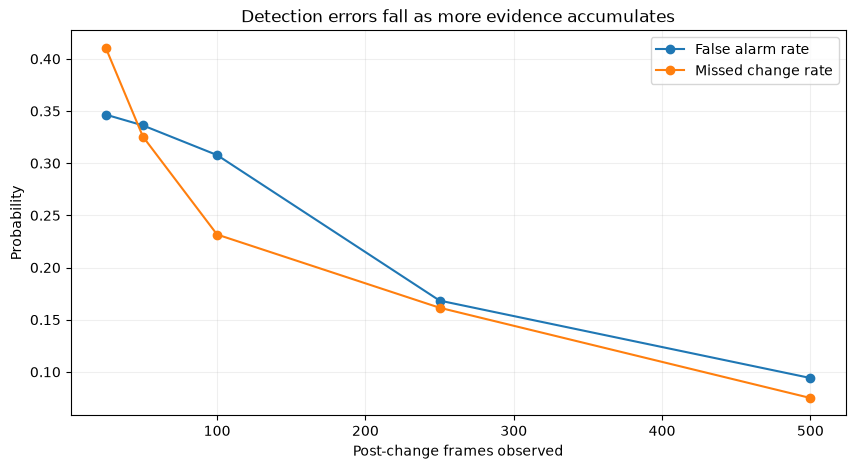

In [8]:
# Show how the two kinds of decision error change as more post-change
# frames become available.
plt.figure(figsize=(10, 5))

plt.plot(
    evidence["frames_observed"],
    evidence["false_alarm_rate"],
    marker="o",
    label="False alarm rate"
)

plt.plot(
    evidence["frames_observed"],
    evidence["missed_change_rate"],
    marker="o",
    label="Missed change rate"
)

plt.xlabel("Post-change frames observed")
plt.ylabel("Probability")
plt.title("Detection errors fall as more evidence accumulates")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Detection improves with time

The chart shows the cost of trying to identify an ability change quickly.

With only a small number of post-change frames, the two possible worlds are difficult to distinguish.

At **25 frames**:

- false-alarm rate = **34.7%**;
- missed-change rate = **41.0%**.

So very early evidence is highly ambiguous.

As more frames accumulate, both types of error fall.

By **250 frames**:

- false-alarm rate = **16.8%**;
- missed-change rate = **16.1%**.

By **500 frames**:

- false-alarm rate = **9.4%**;
- missed-change rate = **7.5%**.

The underlying ability difference has not changed at any point in this comparison.

The player is always either genuinely at 58% or genuinely at 64%.

What changes is simply the amount of evidence available to us.

This exposes a fundamental tension in detecting sporting form:

> **Evidence is weakest when a possible change is newest and most interesting.**

If we react quickly, ordinary randomness can easily fool us.

If we wait for enough evidence to become confident, we are necessarily recognising the change later.

So a detector faces not only a trade-off between false alarms and missed changes, but also a trade-off between **speed and certainty**.

## Conclusion

Study 13 moved from estimation to inference.

In Studies 07–12, the true underlying ability path was known. We could therefore ask how quickly different estimators responded when ability changed.

Here, the true ability was hidden from the detector.

The detector saw only wins and losses.

We compared two controlled worlds:

- **no change:** true frame-win probability remained at 58%;
- **real change:** true frame-win probability increased permanently from 58% to 64%.

Using the first 250 frames after the suspected change point, the expected win totals were:

- 145 wins at 58%;
- 160 wins at 64%.

But ordinary sampling variation caused the two exact binomial distributions to overlap by approximately **33.0%**.

That overlap has a practical consequence.

Using a simple threshold of 153 wins from 250 frames:

- **16.8%** of unchanged 58% players produced a false alarm;
- **16.1%** of genuinely improved 64% players were missed.

Changing the threshold did not remove the uncertainty.

Lower thresholds detected more genuine changes but created more false alarms.

Higher thresholds reduced false alarms but missed more genuine changes.

The problem was not a defective detector.

The observed data themselves were sometimes compatible with either underlying world.

Increasing the amount of evidence helped.

With the same simple midpoint-threshold approach:

- after 25 frames, the detection rate was only **59.0%**;
- after 100 frames, it was **76.8%**;
- after 250 frames, it was **83.9%**;
- after 500 frames, it reached **92.5%**.

False alarms fell at the same time.

So genuine ability change becomes easier to recognise as evidence accumulates.

But that creates a sporting trade-off:

> **The earliest evidence of a possible change is also the least reliable evidence.**

A player can produce an apparently improved run without their underlying ability having changed.

Equally, a player can genuinely improve without their early results providing convincing evidence that anything changed.

The central result of Study 13 is therefore:

> **Observed form does not reveal underlying ability change directly. Random variation can make unchanged and genuinely changed players produce overlapping evidence.**

This adds a new layer to the story developed in Studies 07–12.

Those studies showed that historical results can become stale when ability moves.

Study 13 shows that, before deciding how quickly to forget old results, we face an even more basic problem:

> **We may not yet know whether ability moved at all.**

This is the bridge from **estimating current ability** to **inferring changes in ability from noisy sporting results**.

### Deliberately not addressed

This study did not:

- search for an unknown change point;
- optimise the decision threshold;
- assign different costs to false alarms and missed changes;
- use sequential testing;
- use Bayesian change detection;
- use adaptive windows;
- estimate the size of an unknown ability change;
- allow temporary or gradual changes;
- introduce opponent effects;
- introduce match formats;
- use real-player data.

Those are separate questions.

For now, the important result is simpler:

> **Even when we know where to look and what size of change might have occurred, finite sporting results cannot perfectly distinguish genuine improvement from ordinary randomness.**